In [35]:
import torch
import torch.nn as nn
from data import NH_Haze_Dataset, DENSE_Haze_Dataset
from data.utils import get_haze_transforms, restandardize_tensor
from data.utils import partition_dataset
import matplotlib.pyplot as plt

In [24]:
data_path = "dataset/nh-haze/NH-HAZE"

train_transform = get_haze_transforms("NHHAZE", resize_size = 256, split = "train", verbose = True)
val_transform = get_haze_transforms("NHHAZE", resize_size = 256, split = "val", verbose = True)

train_dataset = NH_Haze_Dataset(root_dir = data_path, split = "train", transform = train_transform)
val_dataset = NH_Haze_Dataset(root_dir = data_path, split = "val", transform = val_transform)


╭─────────────────────────────────── Augmentation Pipeline ────────────────────────────────────╮
│ NHHAZE | TRAIN | 256x256                                                                     │
│ ├── 1. Geometric (Synchronous)                                                               │
│ │   ├── Applies identically to CLEAR & HAZY for alignment                                    │
│ │   └── Compose(                                                                             │
│ │             RandomCrop(size=(256, 256), pad_if_needed=True, fill=0, padding_mode=constant) │
│ │             RandomHorizontalFlip(p=0.5)                                                    │
│ │             RandomVerticalFlip(p=0.5)                                                      │
│ │       )                                                                                    │
│ ├── 2. Appearance (Hazy-Only)                                                                │
│ │   ├── Simulates real-world haze variations                                                 │
│ │   └── Compose(                                                                             │
│ │             ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.9, 1.1)) │
│ │             RandomGrayscale(p=0.15)                                                        │
│ │       )                                                                                    │
│ └── 3. Common (Tensor & Norm)                                                                │
│     ├── Final prep: ToTensor, Normalize                                                      │
│     └── Compose(                                                                             │
│               ToImage()                                                                      │
│               ToDtype(scale=True)                                                            │
│               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=False)            │
│         )                                                                                    │
╰──────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────── Augmentation Pipeline ──────────────────────────────╮
│ NHHAZE | VAL/TEST | Original Size                                                 │
│ ├── 1. Geometric (Synchronous)                                                    │
│ │   ├── Applies identically to CLEAR & HAZY for alignment                         │
│ │   └── Identity()                                                                │
│ ├── 2. Appearance (Hazy-Only)                                                     │
│ │   ├── Simulates real-world haze variations                                      │
│ │   └── Identity()                                                                │
│ └── 3. Common (Tensor & Norm)                                                     │
│     ├── Final prep: ToTensor, Normalize                                           │
│     └── Compose(                                                                  │
│               ToImage()                                                           │
│               ToDtype(scale=True)                                                 │
│               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=False) │
│         )                                                                         │
╰───────────────────────────────────────────────────────────────────────────────────╯

In [31]:
clean, hazy = train_dataset[0]
# clean, hazy = val_dataset[1]

In [32]:
clean_vis = restandardize_tensor(clean)
hazy_vis = restandardize_tensor(hazy)

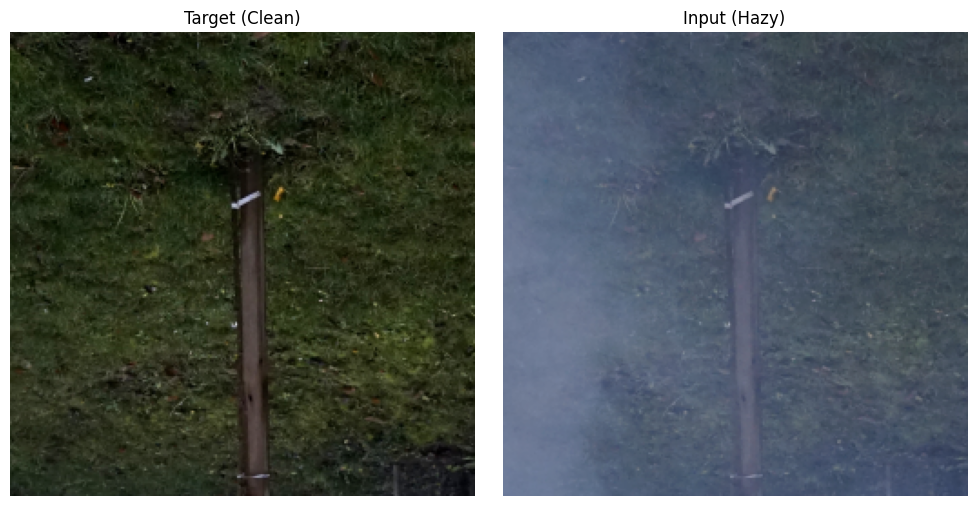

In [33]:
def show_pair(clean_t, hazy_t):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Permute (C, H, W) -> (H, W, C) for Matplotlib
    clean_np = clean_t.permute(1, 2, 0).cpu().numpy()
    hazy_np = hazy_t.permute(1, 2, 0).cpu().numpy()

    axes[0].imshow(clean_np)
    axes[0].set_title("Target (Clean)")
    axes[0].axis("off")

    axes[1].imshow(hazy_np)
    axes[1].set_title("Input (Hazy)")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

show_pair(clean_vis, hazy_vis)

### Testing loading the dense haze

In [38]:
data_path = "dataset/dense-haze"

train_transform = get_haze_transforms("DENSEHAZE", resize_size = 256, split = "train", verbose = True)
val_transform = get_haze_transforms("DENSEHAZE", resize_size = 256, split = "val", verbose = True)

# train_dataset = NH_Haze_Dataset(root_dir = data_path, split = "train", transform = train_transform)
# val_dataset = NH_Haze_Dataset(root_dir = data_path, split = "val", transform = val_transform)
densehaze_dataset = DENSE_Haze_Dataset(data_path)

# The standard split to train the Dense-HAZE
train_dataset, val_dataset = partition_dataset(
    densehaze_dataset, 
    train_transform, 
    val_transform, 
    train_ratio = 0.91
)

print(f"Length of train dataset: {len(train_dataset)}")
print(f"Length of val dataset: {len(val_dataset)}")



╭────────────────────────────────────── Augmentation Pipeline ───────────────────────────────────────╮
│ DENSEHAZE | TRAIN | 256x256                                                                        │
│ ├── 1. Geometric (Synchronous)                                                                     │
│ │   ├── Applies identically to CLEAR & HAZY for alignment                                          │
│ │   └── Compose(                                                                                   │
│ │             RandomCrop(size=(256, 256), pad_if_needed=True, fill=0, padding_mode=constant)       │
│ │             RandomHorizontalFlip(p=0.5)                                                          │
│ │             RandomVerticalFlip(p=0.5)                                                            │
│ │       )                                                                                          │
│ ├── 2. Appearance (Hazy-Only)                                                                      │
│ │   ├── Simulates real-world haze variations                                                       │
│ │   └── Compose(                                                                                   │
│ │             ColorJitter(brightness=(0.95, 1.05), contrast=(0.95, 1.05), saturation=(0.95, 1.05)) │
│ │             RandomGrayscale(p=0.2)                                                               │
│ │       )                                                                                          │
│ └── 3. Common (Tensor & Norm)                                                                      │
│     ├── Final prep: ToTensor, Normalize                                                            │
│     └── Compose(                                                                                   │
│               ToImage()                                                                            │
│               ToDtype(scale=True)                                                                  │
│               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=False)                  │
│         )                                                                                          │
╰────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────── Augmentation Pipeline ──────────────────────────────╮
│ DENSEHAZE | VAL/TEST | Original Size                                              │
│ ├── 1. Geometric (Synchronous)                                                    │
│ │   ├── Applies identically to CLEAR & HAZY for alignment                         │
│ │   └── Identity()                                                                │
│ ├── 2. Appearance (Hazy-Only)                                                     │
│ │   ├── Simulates real-world haze variations                                      │
│ │   └── Identity()                                                                │
│ └── 3. Common (Tensor & Norm)                                                     │
│     ├── Final prep: ToTensor, Normalize                                           │
│     └── Compose(                                                                  │
│               ToImage()                                                           │
│               ToDtype(scale=True)                                                 │
│               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=False) │
│         )                                                                         │
╰───────────────────────────────────────────────────────────────────────────────────╯

Length of train dataset: 50
Length of val dataset: 5


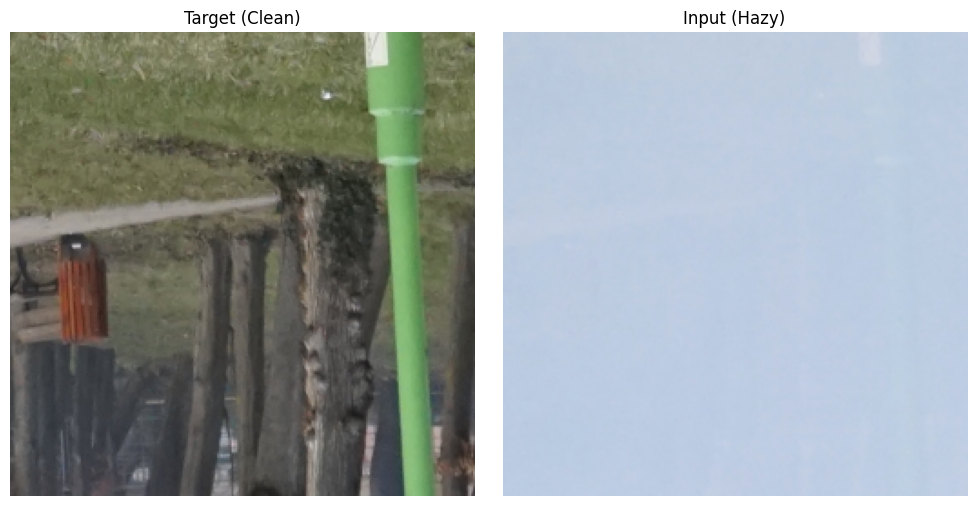

In [46]:
clean, hazy = train_dataset[0]

clean_vis = restandardize_tensor(clean)
hazy_vis = restandardize_tensor(hazy)

show_pair(clean_vis, hazy_vis)

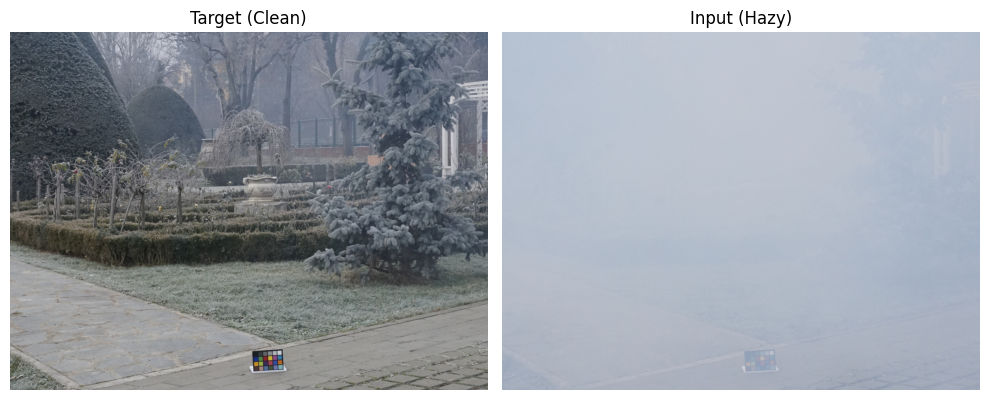

In [48]:
clean, hazy = val_dataset[1]

clean_vis = restandardize_tensor(clean)
hazy_vis = restandardize_tensor(hazy)

show_pair(clean_vis, hazy_vis)

In [50]:
clean_vis.shape

torch.Size([3, 1200, 1600])

## Test the loading pipeline as dataloader